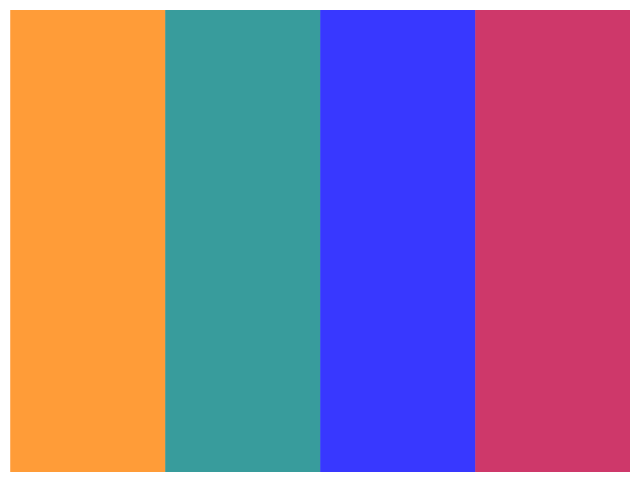

In [71]:
# read json file
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Set up professional plotting style
rcParams.update({
    'font.size': 14,
    'figure.figsize': (8, 6),
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'lines.linewidth': 2,
    'lines.markersize': 8,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',

    # Remove top/right spines globally
    'axes.spines.top': False,
    'axes.spines.right': False,
})
import matplotlib.colors as mcolors

#colors_hex = ["ffb56a", "6ab5b5", "6a6aff", "da6a8f"]
colors_hex = ["ff9c38", "389c9c", "3838ff", "ce386a"]
colors_rgb = [mcolors.to_rgb(f"#{c}") for c in colors_hex]
colors = colors_rgb
# plot four colors
fig, ax = plt.subplots()
for i, color in enumerate(colors):
    ax.plot([i, i], [0, 1], color=color, linewidth=112)
# set limits and ticks off
ax.set_xlim(-0.5, 3.5)
ax.set_ylim(0, 1)
ax.axis('off')
# save figure
#plt.savefig("color_palette.png", bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()


In [3]:
#file_path = "fm/fm-val-b200/ms_error/individual_rollout_rae_pdebench-incomp.json"
file_path = "old_data/fm/fm-val-b200/ms_error/individual_rollout_rae_pdebench-comp.json"
#file_path = "fm/fm-val-b200/ms_error/individual_rollout_rae_amira.json"
# print all files in the directory
directory = os.path.dirname(file_path)
for filename in os.listdir(directory):
    if filename.startswith("individual") and not filename.endswith("amira.json") and not filename.endswith("incomp.json"):
        #print(filename)
        with open(os.path.join(directory, filename), "r") as f:
            data = json.load(f)
        # the jsons consist of nested lists, print the size of the outermost list
        print(f"File: {filename},\ndim0: {len(data)}") 
        # print the keys of the first element in the outermost list
        print(f"dim1: {len(data[0])}")
        # print the keys of the first element in the innermost list 
        print(f"dim2: {len(data[0][0])}")
        # print the length of the innermost list
        print("-----")



FileNotFoundError: [Errno 2] No such file or directory: 'old_data/fm/fm-val-b200/ms_error'

Dataset: amira, FM shape: (16,), AR shape: ()
Dataset: pdebench-comp, FM shape: (16,), AR shape: ()
Dataset: pdebench-incomp, FM shape: (16,), AR shape: ()
Dataset: pdegym-gauss, FM shape: (16,), AR shape: ()
Dataset: pdegym-sines, FM shape: (16,), AR shape: ()
Dataset: pdegym-sl, FM shape: (16,), AR shape: ()
Dataset: pdegym-svs, FM shape: (16,), AR shape: ()
Dataset: pdegym-pwc, FM shape: (16,), AR shape: ()
Dataset: pdegym-bb, FM shape: (16,), AR shape: ()


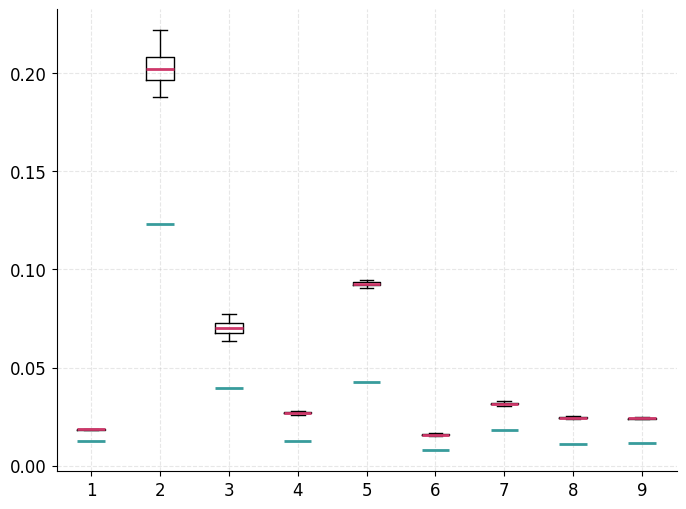

In [72]:
base_path_ar = "../../../FluidGPT_validation/temp_data/val-ar-tiny/ss_error/"
base_path_fm = "../../../FluidGPT_validation/old_data/fm/fm-val-b200/ss_error/"
error_type = "rae"  # or "rrmse"
list_avg_ar = []
list_fm_data = []

for dataset_name in ["amira", "pdebench-comp", "pdebench-incomp", "pdegym-gauss", "pdegym-sines", "pdegym-sl", "pdegym-svs", "pdegym-pwc", "pdegym-bb"]:
    filename_ar = f"{base_path_ar}individual_{error_type}_{dataset_name}.json"
    filename_fm = f"{base_path_fm}individual_{error_type}_{dataset_name}.json"

    with open(filename_fm, "r") as f:
        data_fm = np.array(json.load(f))
    with open(filename_ar, "r") as f:
        data_ar = np.array(json.load(f))

    data_fm = np.sort(data_fm)
    data_ar = np.sort(data_ar)
    avg_ar = np.mean(data_ar, axis=0)
    avg_fm = np.mean(data_fm, axis=0)
    print(f"Dataset: {dataset_name}, FM shape: {avg_fm.shape}, AR shape: {avg_ar.shape}")
    list_avg_ar.append(avg_ar)
    list_fm_data.append(avg_fm)

fig, ax = plt.subplots()
bp = ax.boxplot(list_fm_data, widths=0.4)
for i, item in enumerate(list_avg_ar):
    x_center = i + 1
    box_width = 0.4  # default matplotlib box width

    y_ref = item
    ax.hlines(
        y=y_ref,
        xmin=x_center - box_width / 2,
        xmax=x_center + box_width / 2,
        linewidth=2,
        color=colors[1]
    )
for median in bp["medians"]:
    median.set(color=colors[3], linewidth=2)

data_fm shape: (21, 8800, 16), data_ar shape: (21, 8800)
avg_fm shape: (21,), avg_ar shape: (21,)


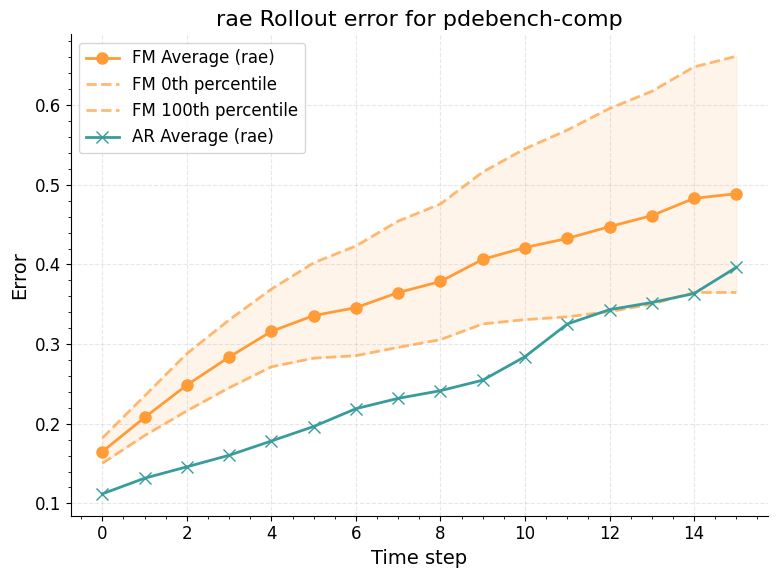

data_fm shape: (21, 4000, 16), data_ar shape: (21, 4000)
avg_fm shape: (21,), avg_ar shape: (21,)


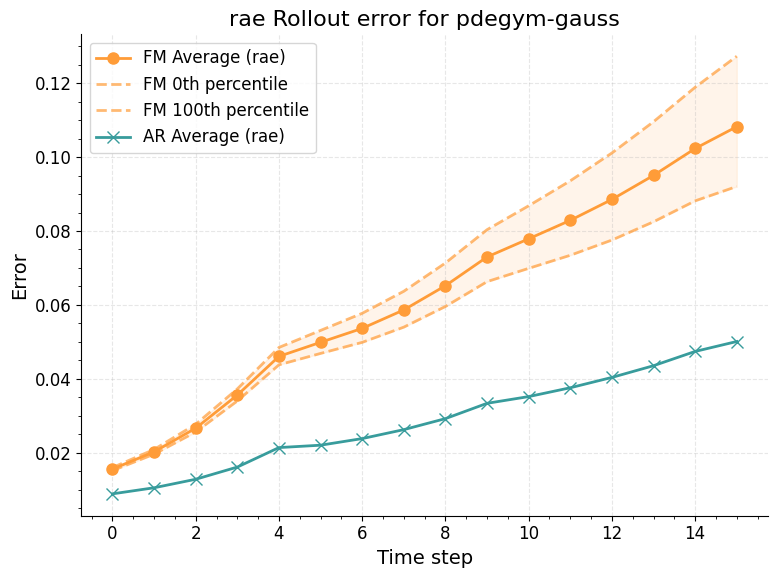

data_fm shape: (21, 4000, 16), data_ar shape: (21, 4000)
avg_fm shape: (21,), avg_ar shape: (21,)


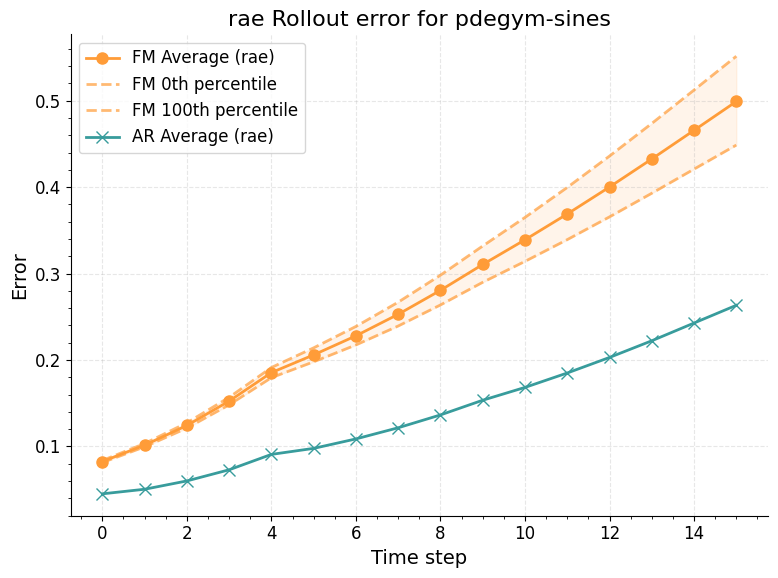

data_fm shape: (21, 5916, 16), data_ar shape: (21, 5916)
avg_fm shape: (21,), avg_ar shape: (21,)


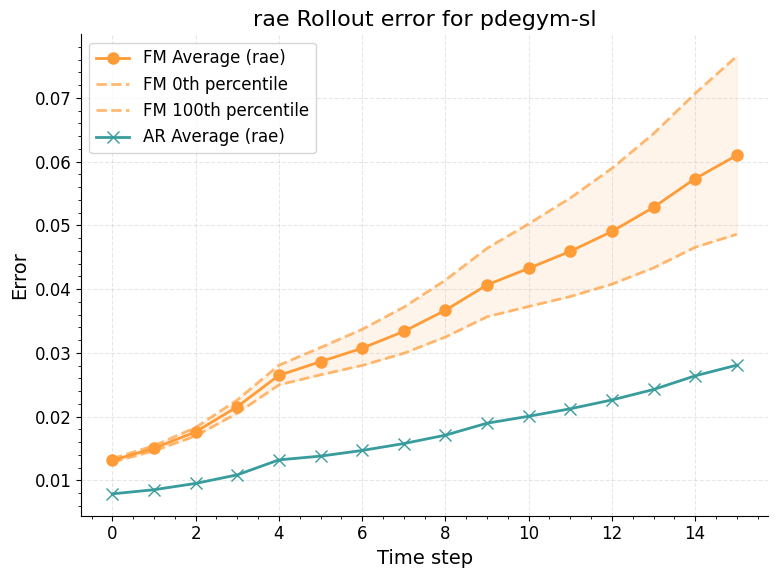

data_fm shape: (21, 4000, 16), data_ar shape: (21, 4000)
avg_fm shape: (21,), avg_ar shape: (21,)


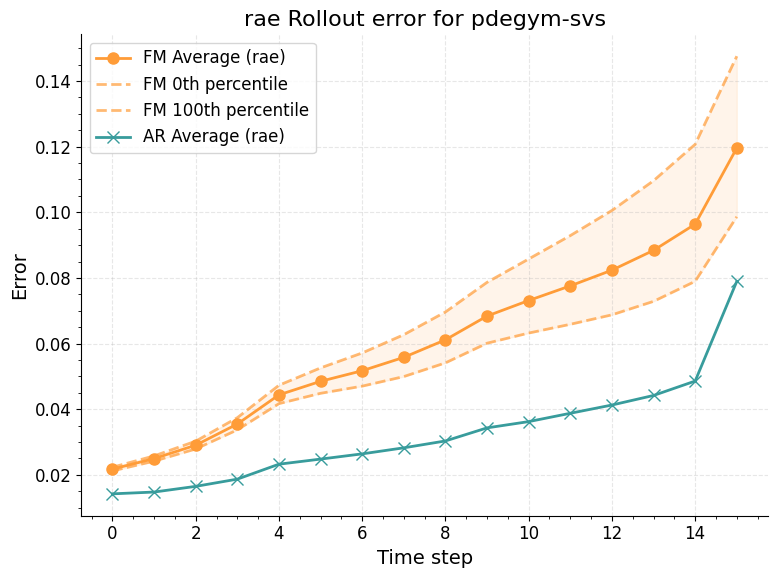

data_fm shape: (21, 4000, 16), data_ar shape: (21, 4000)
avg_fm shape: (21,), avg_ar shape: (21,)


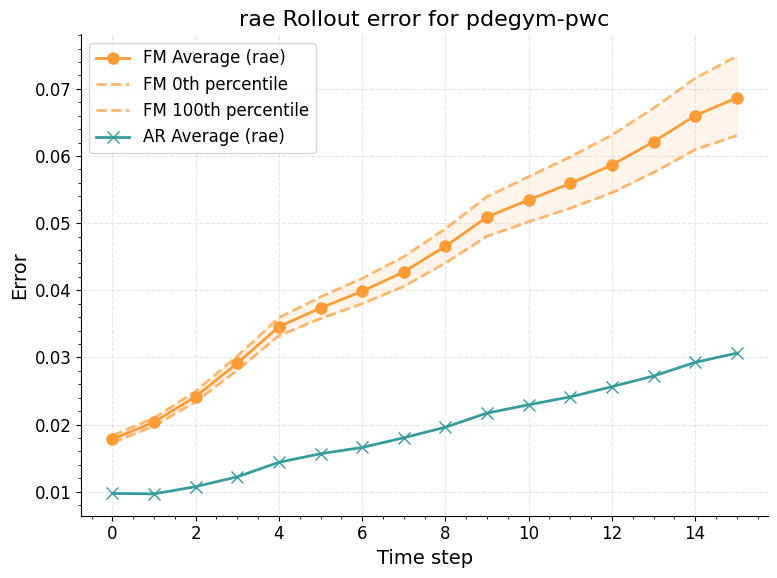

data_fm shape: (21, 4000, 16), data_ar shape: (21, 4000)
avg_fm shape: (21,), avg_ar shape: (21,)


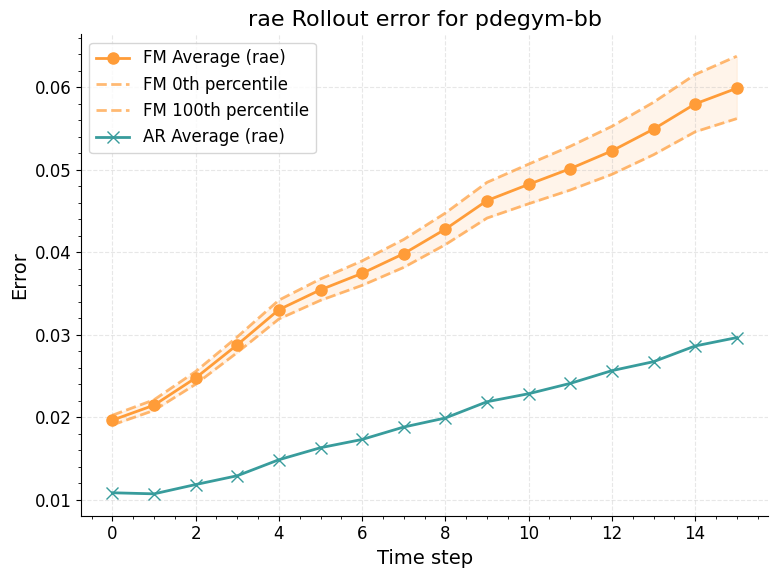

In [73]:
base_path_ar = "../../../FluidGPT_validation/temp_data/val-ar-tiny/ms_error/"
base_path_fm = "../../../FluidGPT_validation/old_data/fm/fm-val-b200/ms_error/"
error_type = "rae"  # or "rrmse"

tb = 5
for dataset_name in ["amira", "pdebench-comp", "pdebench-incomp", "pdegym-gauss", "pdegym-sines", "pdegym-sl", "pdegym-svs", "pdegym-pwc", "pdegym-bb"]:
    if dataset_name == "amira" or dataset_name == "pdebench-incomp":
        continue
    filename_ar = f"{base_path_ar}individual_rollout_{error_type}_{dataset_name}.json"
    filename_fm = f"{base_path_fm}individual_rollout_{error_type}_{dataset_name}.json"

    with open(filename_ar, "r") as f:
        data_ar = np.array(json.load(f))
    with open(filename_fm, "r") as f:
        data_fm = np.array(json.load(f))

    fig, ax = plt.subplots()
    print(f"data_fm shape: {data_fm.shape}, data_ar shape: {data_ar.shape}")
    avg_fm = np.mean(data_fm, axis=(1,2))
    avg_ar = np.mean(data_ar, axis=1)
    print(f"avg_fm shape: {avg_fm.shape}, avg_ar shape: {avg_ar.shape}")
    q0, q25, q50, q75, q100 = np.quantile(data_fm, [0, 0.25, 0.5, 0.75, 1], axis=(2))
    #compute the mean of the quantiles over axis 1
    q0 = np.mean(q0, axis=1)
    q25 = np.mean(q25, axis=1)
    q50 = np.mean(q50, axis=1)
    q75 = np.mean(q75, axis=1)
    q100 = np.mean(q100, axis=1)
    
    # remove first tb elements
    avg_fm = avg_fm[tb:]
    avg_ar = avg_ar[tb:]
    q0 = q0[tb:]
    q25 = q25[tb:]
    q50 = q50[tb:]
    q75 = q75[tb:]
    q100 = q100[tb:]

    ax.plot(avg_fm, 'o-', color=colors[0], label='FM Average' + f' ({error_type})')
    ax.plot(q0, '--', color=colors[0], alpha=0.7, label='FM 0th percentile')
    #ax.plot(q50, '--', color=colors[0], alpha=0.9, label='FM Median')
    ax.plot(q100, '--', color=colors[0], alpha=0.7, label='FM 100th percentile')
    ax.plot(avg_ar, 'x-', color=colors[1], label='AR Average' + f' ({error_type})')
    plt.fill_between(range(len(avg_fm)), q0, q100, color=colors[0], alpha=0.1)

    ax.set_xlabel("Time step")
    ax.set_ylabel("Error")
    ax.set_title(f"{error_type} Rollout error for {dataset_name}")
    ax.legend(loc='upper left')  
    ax.minorticks_on()

    plt.tight_layout()
    plt.show()


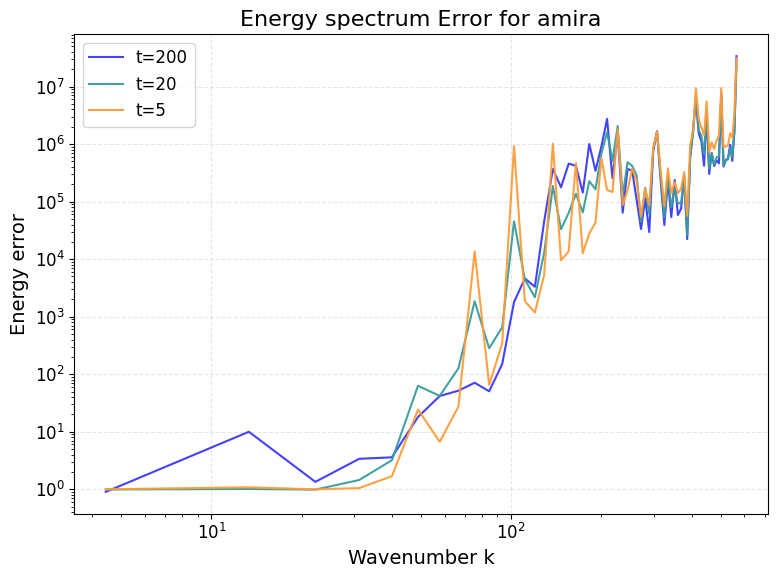

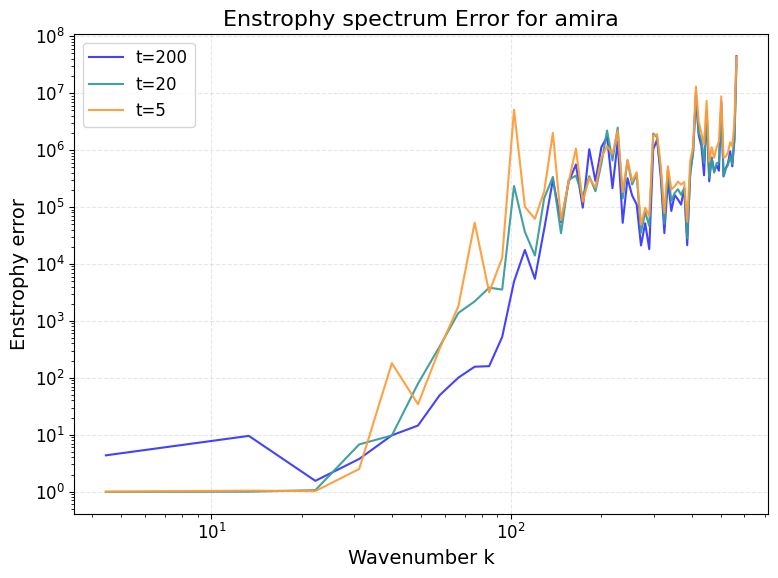

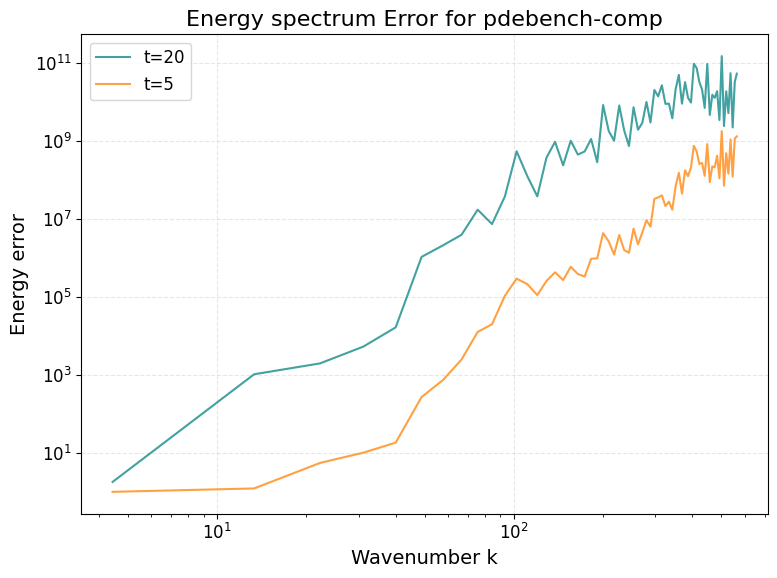

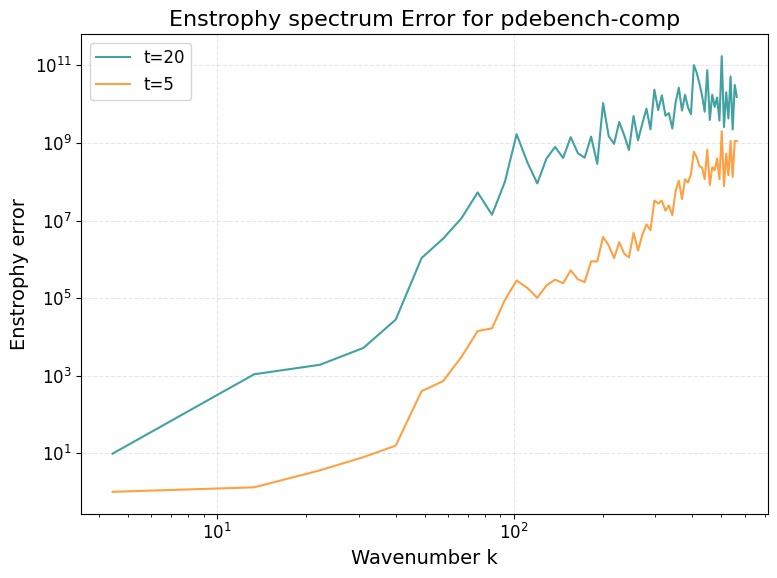

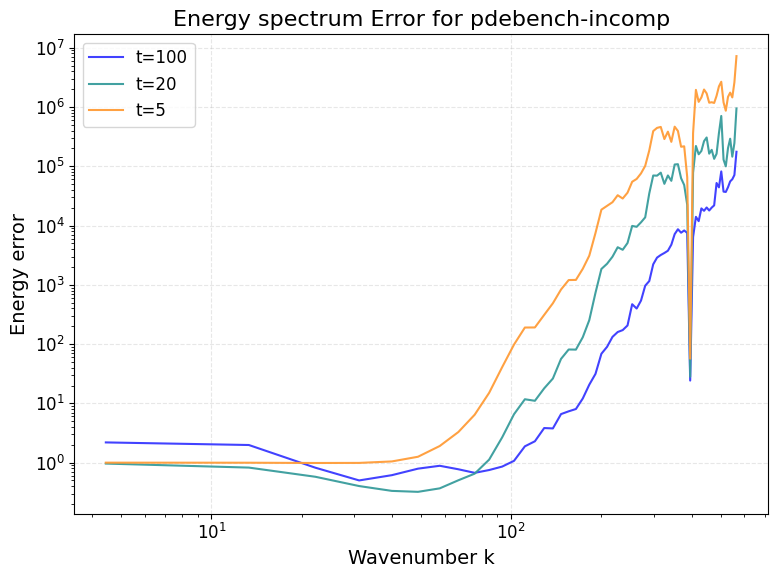

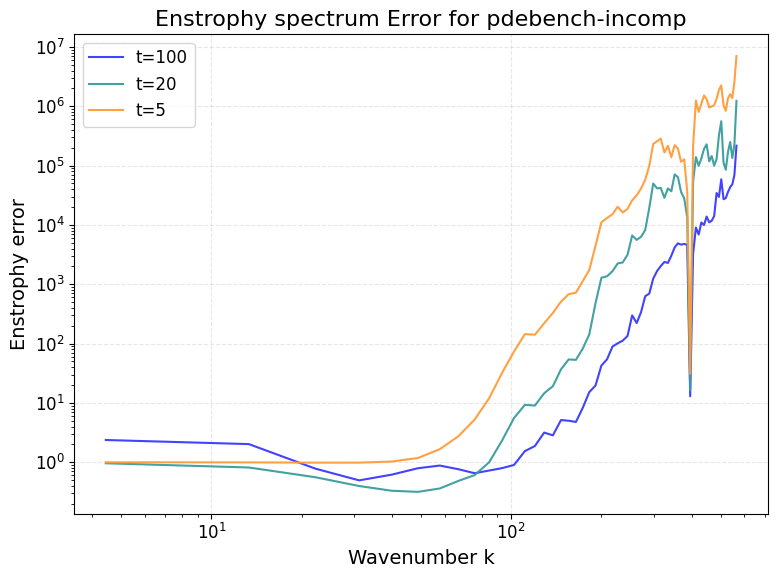

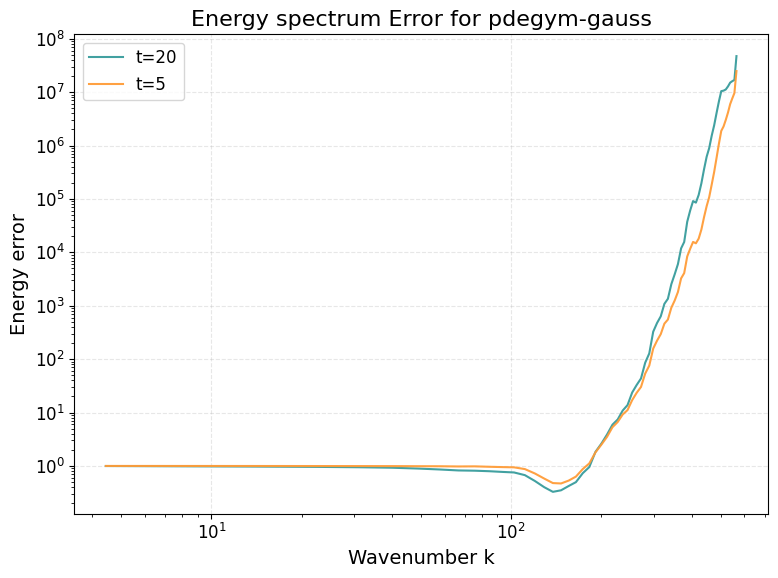

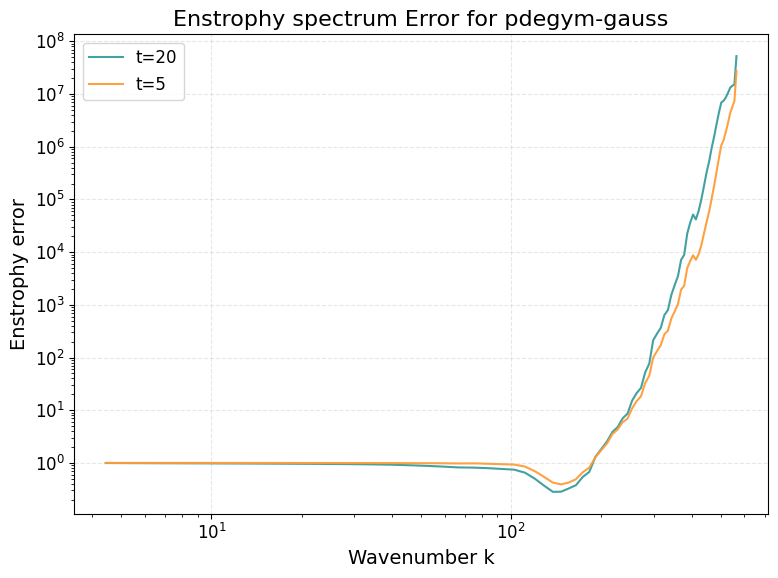

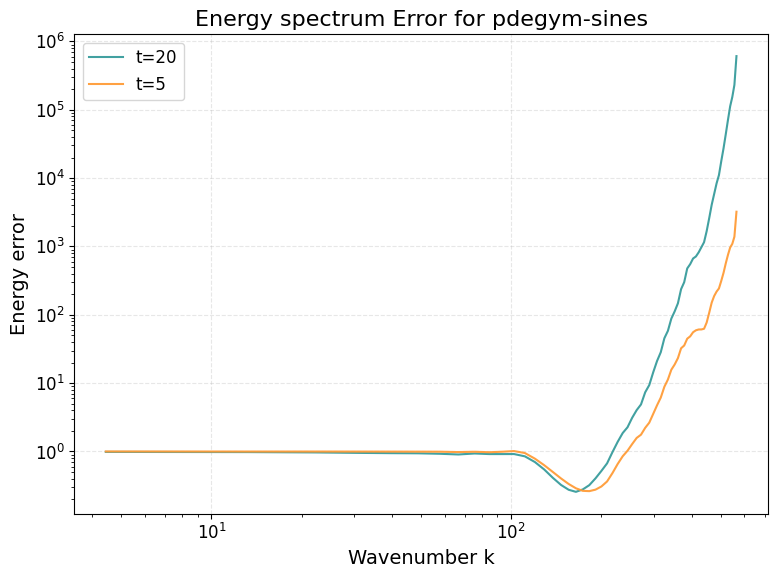

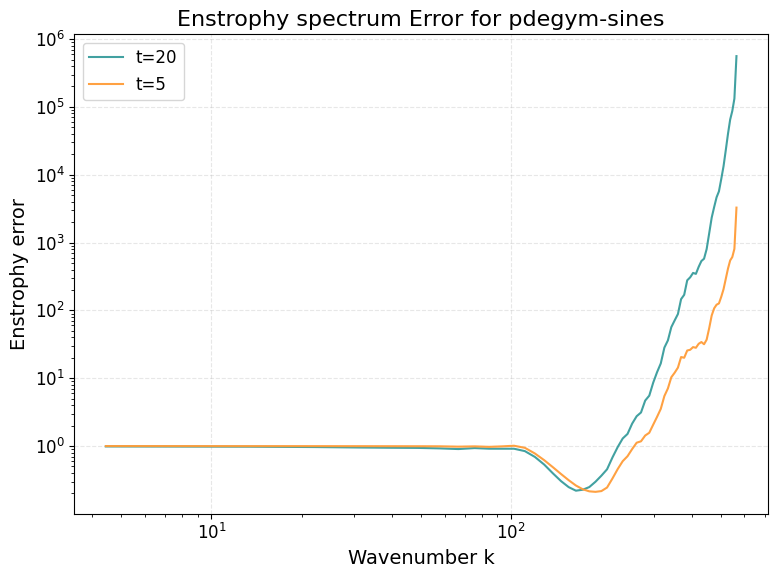

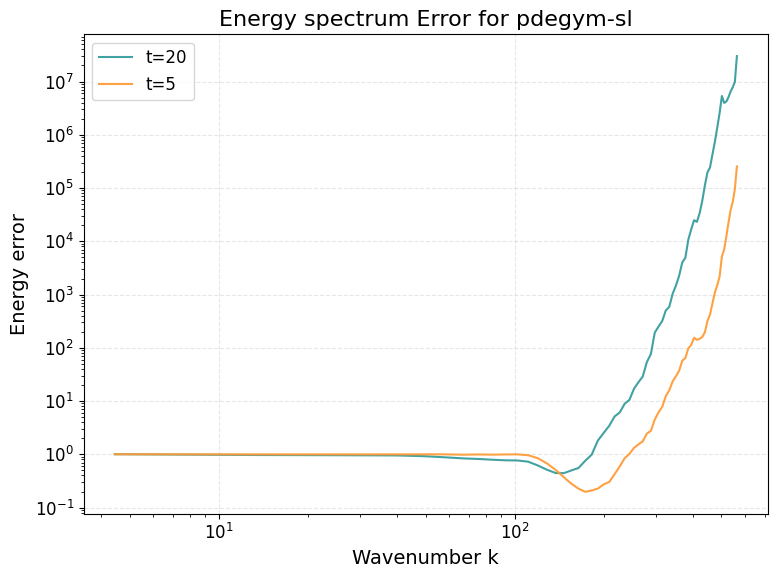

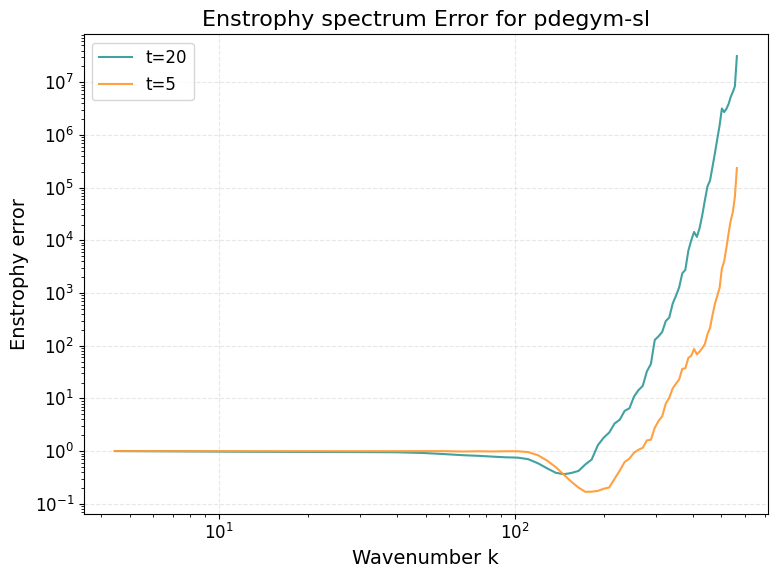

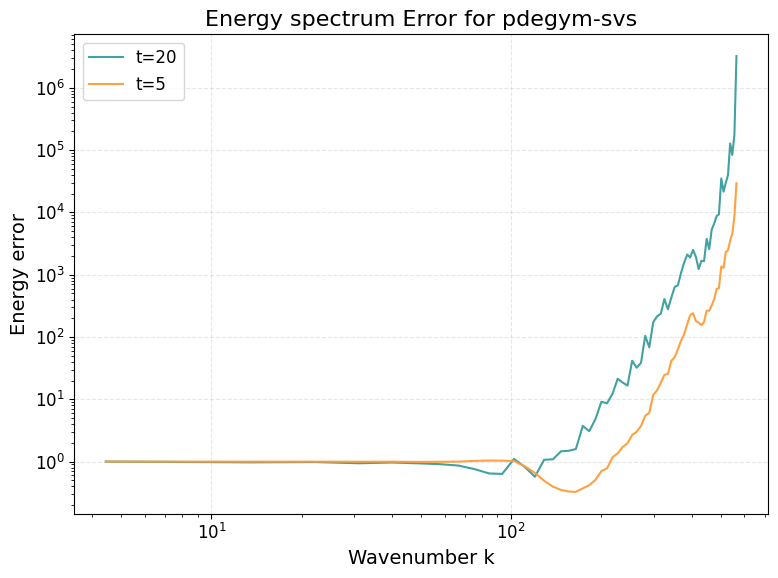

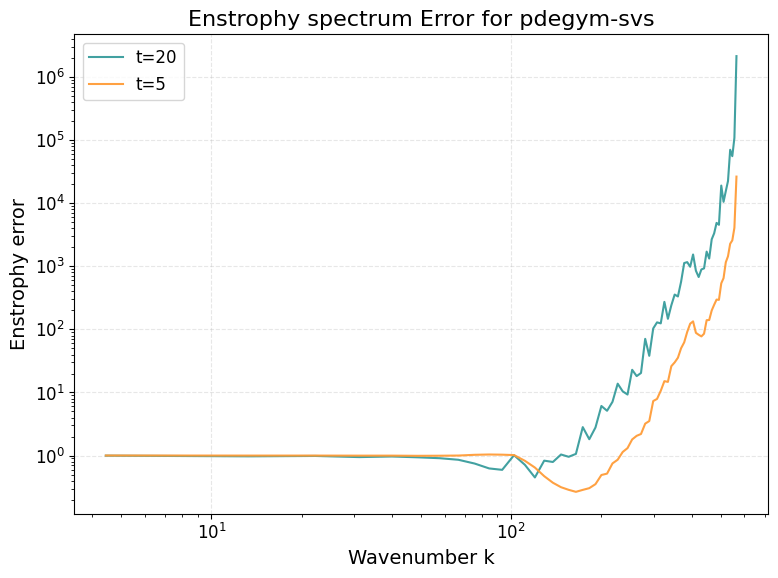

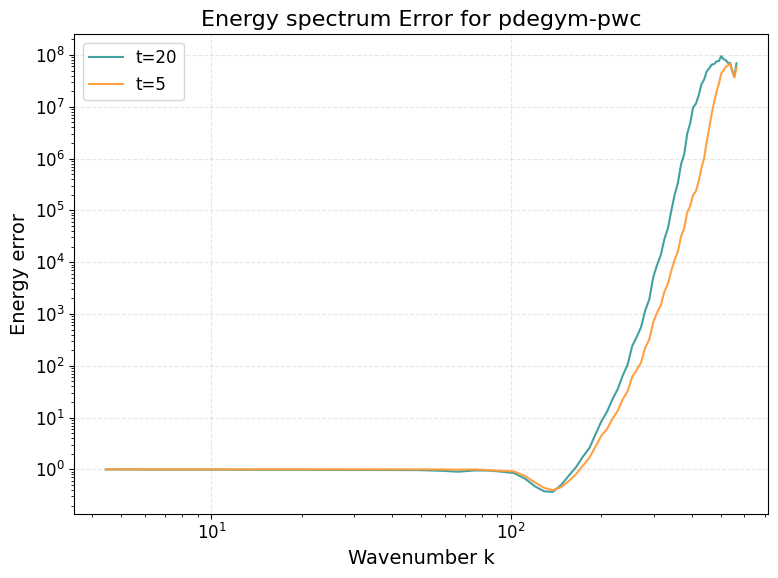

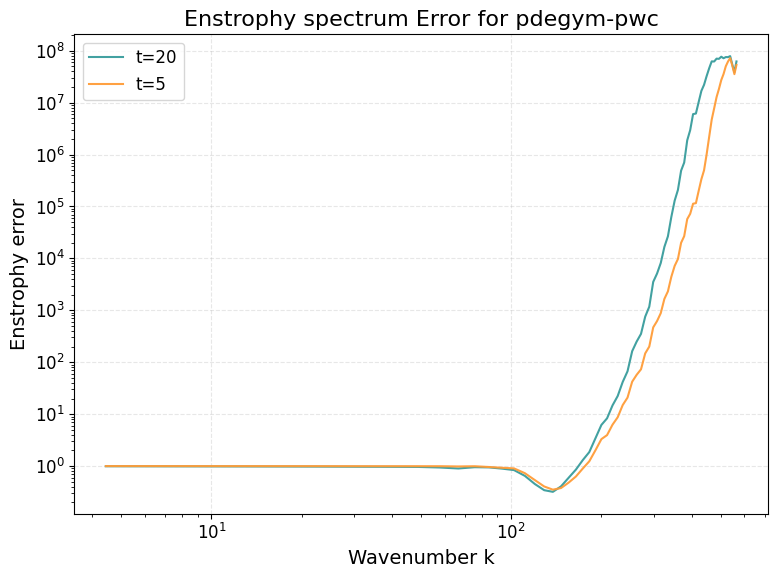

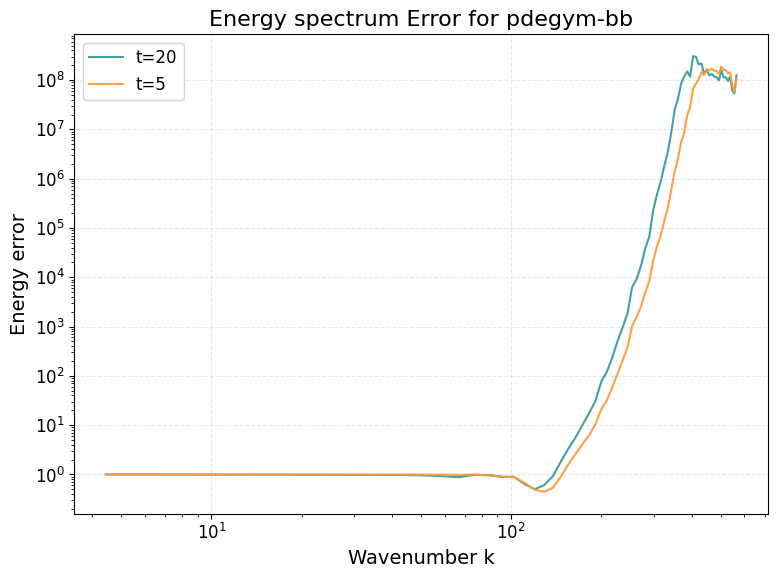

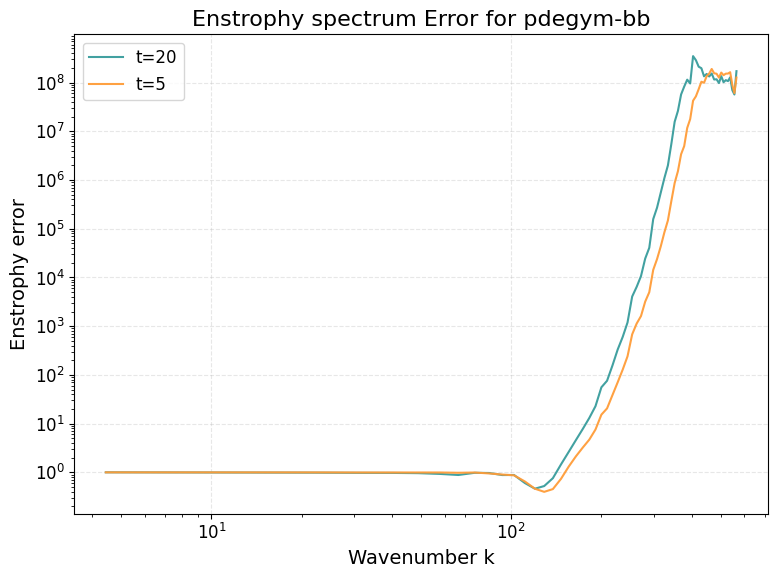

In [42]:
# loop over dataset
# loop over E or Z spectra
# loop over files that belong to that dataset
base_path = "../../../FluidGPT_validation/temp_data/val-ar-tiny/spectra_error/"
spectrum_actual = ["Energy", "Enstrophy"]


for dataset_name in ["amira", "pdebench-comp", "pdebench-incomp", "pdegym-gauss", "pdegym-sines", "pdegym-sl", "pdegym-svs", "pdegym-pwc", "pdegym-bb"]:
    for spectrum_type, spectrum_name in zip(["E", "Z"], spectrum_actual):
        
        if dataset_name == "amira" or dataset_name == "pdebench-incomp":
            timestep_list = ["=5", "=20", "final"]
            if dataset_name == "amira":
                timestep_actual = ["5", "20", "200"]
            if dataset_name == "pdebench-incomp":
                timestep_actual = ["5", "20", "100"]
        else:
            timestep_list = ["=5", "=20"]
            timestep_actual = ["5", "20"]
        k_filename = f"{base_path}k_steps_{dataset_name}.json"
        #print(k_filename)
        with open(k_filename, "r") as f:
            k_steps = json.load(f)
        #print(f"k_steps length: {len(k_steps)}")
        # create figure
        fig, ax = plt.subplots()
        for c, (t, timestep) in reversed(list(enumerate(zip(timestep_actual, timestep_list)))):
            
            filename = f"{base_path}{spectrum_type}spec_t{timestep}_{dataset_name}.json"
            
            #print(filename)
            with open(filename, "r") as f:
                data = np.array(json.load(f))
            #print(f"data shape: {data.shape}")
            avg_data = np.mean(data, axis=1)
            ax.plot(k_steps, avg_data, label=f't={t}', linewidth=1.5, color=colors[c], alpha=0.95)
        #print()
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel("Wavenumber k")
        ax.set_ylabel(f"{spectrum_name} error")
        ax.set_title(f"{spectrum_name} spectrum Error for {dataset_name}")
        ax.legend(loc='upper left')
        ax.minorticks_on()
        plt.tight_layout()
        plt.show()


